<table>
    <tr>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center"><FONT COLOR="blue">Entregable 3<br>K-means y PCA<br>Métodos de Ensamble</FONT></h1>
        </td>
        <td>
            <p style="font-size:99%;text-align:center">Aprendizaje Automático de Máquina</p>
            <p style="font-size:115%;text-align:center">Pregrado MACC 2026-1</p>
            <p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p>
        </td>
    </tr>
</table>

**Integrantes:**
- Nombre 1
- Nombre 2
- Nombre 3

# <FONT COLOR="Purple"> 1. PCA </FONT>

## 1.1 Librerías

In [1]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn           as sns
import plotly.express    as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

## 1.2 Cargar y explorar los datos

In [2]:
paises = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_paises.csv")
paises.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [3]:
# Información general
paises.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
# Estadísticas descriptivas
paises.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [5]:
# Verificar valores faltantes
paises.isna().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


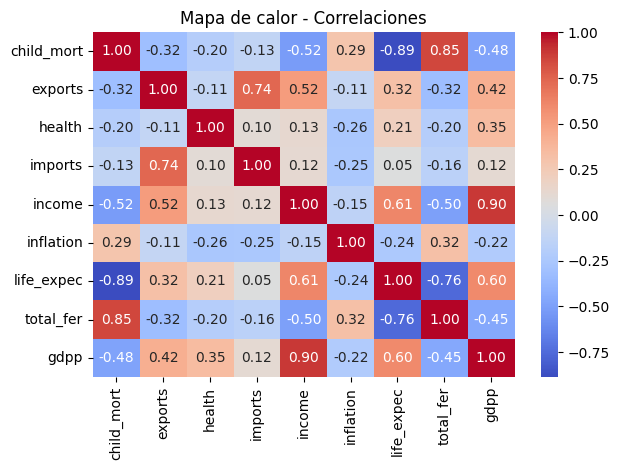

In [6]:
# Matriz de correlación
corr = paises.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor - Correlaciones")
plt.tight_layout()
plt.show()

## 1.3 Análisis de PCA

In [7]:
# Separar la columna de país y quedarse con variables numéricas
paises_num = paises.select_dtypes(include="number").dropna()
nombres_paises = paises.loc[paises_num.index, paises.columns[0]]

# Estandarizar los datos
paises_std = StandardScaler().fit_transform(paises_num)

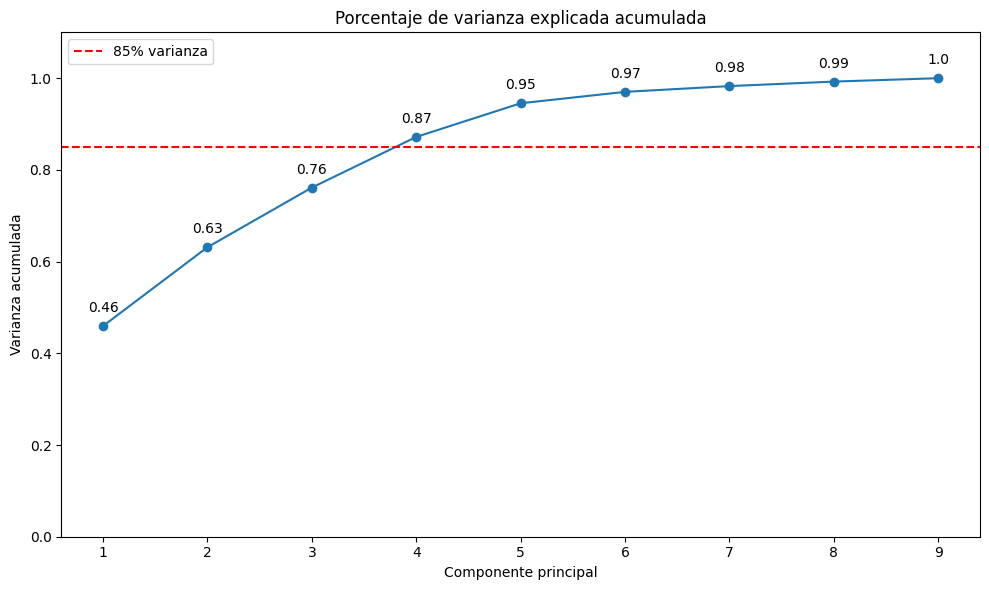

In [8]:
# Ajustar PCA con todas las componentes para ver varianza explicada
pca_full = PCA()
pca_full.fit(paises_std)

# Porcentaje de varianza explicada acumulada
prop_varianza_acum = pca_full.explained_variance_ratio_.cumsum()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(np.arange(len(prop_varianza_acum)) + 1, prop_varianza_acum, marker="o")
for x, y in zip(np.arange(len(prop_varianza_acum)) + 1, prop_varianza_acum):
    ax.annotate(round(y, 2), (x, y), textcoords="offset points", xytext=(0, 10), ha="center")
ax.axhline(y=0.85, color="red", linestyle="--", label="85% varianza")
ax.set_ylim(0, 1.1)
ax.set_xticks(np.arange(len(prop_varianza_acum)) + 1)
ax.set_title("Porcentaje de varianza explicada acumulada")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Varianza acumulada")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# PCA con 2 componentes
pca = PCA(n_components=2)
pca.fit(paises_std)
pca_proj = pca.transform(paises_std)

print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)
print(f"Varianza total retenida: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Varianza explicada por cada componente: [0.4595174  0.17181626]
Varianza total retenida: 63.13%


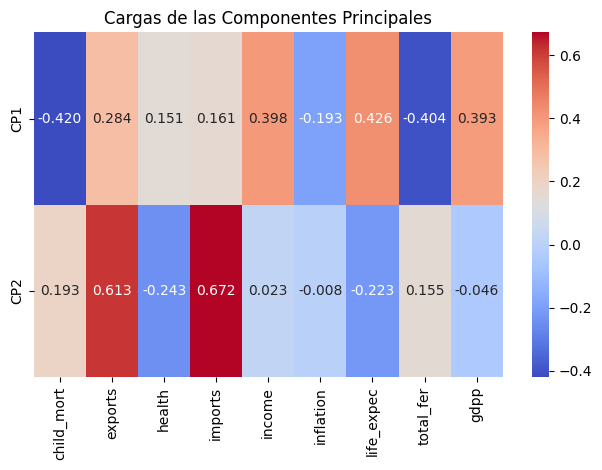

In [10]:
# Heatmap de las componentes (cargas / loadings)
sns.heatmap(pca.components_,
            xticklabels=paises_num.columns,
            yticklabels=["CP1", "CP2"],
            cmap="coolwarm",
            fmt=".3f",
            annot=True)
plt.title("Cargas de las Componentes Principales")
plt.tight_layout()
plt.show()

In [11]:
# Proyección de los países en las 2 primeras componentes
proyecciones = pd.DataFrame(pca_proj, columns=["PC1", "PC2"], index=paises_num.index)
proyecciones["Pais"] = nombres_paises.values

fig = px.scatter(proyecciones,
                 x="PC1", y="PC2",
                 text="Pais",
                 title="Proyección PCA - Países")
fig.update_traces(textposition="top center")
fig.show()

## 1.4 Biplot

In [12]:
!pip install pca -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 kB 6.9 MB/s eta 0:00:00


[04-05-2026 01:17:09] [pca.pca] [INFO] Extracting column labels from dataframe.
[04-05-2026 01:17:09] [pca.pca] [INFO] Extracting row labels from dataframe.
[04-05-2026 01:17:09] [pca.pca] [INFO] Normalizing input data per feature (zero mean and unit variance)..
[04-05-2026 01:17:09] [pca.pca] [INFO] The PCA reduction is performed on 9 variables (columns) of the input dataframe.
[04-05-2026 01:17:09] [pca.pca] [INFO] Fit using PCA.
[04-05-2026 01:17:09] [pca.pca] [INFO] Compute loadings and PCs.
[04-05-2026 01:17:09] [pca.pca] [INFO] Compute explained variance.
[04-05-2026 01:17:09] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[2]
[04-05-2026 01:17:09] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[04-05-2026 01:17:09] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]
[04-05-2026 01:17:09] [pca.pca] [WARNING] Parameter <label> is deprecated and will not be supported in future version.
[

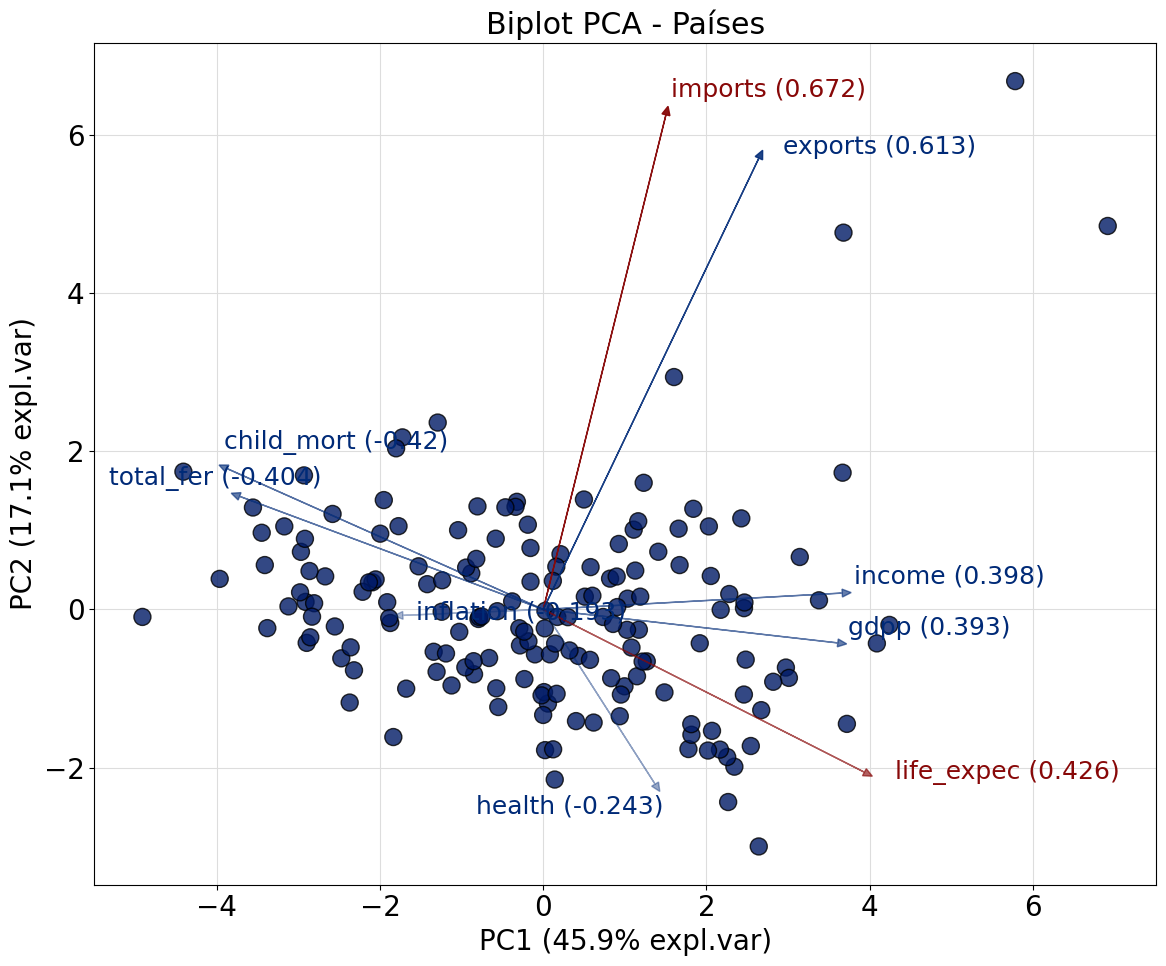

In [13]:
from pca import pca

model_pca = pca(n_components=2, normalize=True)
out = model_pca.fit_transform(paises_num)

# Biplot con etiquetas
fig, ax = model_pca.biplot(label=True, legend=True, figsize=(12, 10))
plt.title("Biplot PCA - Países")
plt.tight_layout()
plt.show()

## 1.5 Conclusiones PCA

> *Escriba aquí sus conclusiones sobre el análisis PCA: qué componentes retienen mayor varianza, qué variables tienen más peso en cada componente, qué grupos de países se distinguen, etc.*

# <FONT COLOR="Purple"> 2. K-means </FONT>

## 2.1 Librerías adicionales

In [14]:
from sklearn.cluster  import KMeans
from sklearn.metrics  import silhouette_score

## 2.2 Método del Codo

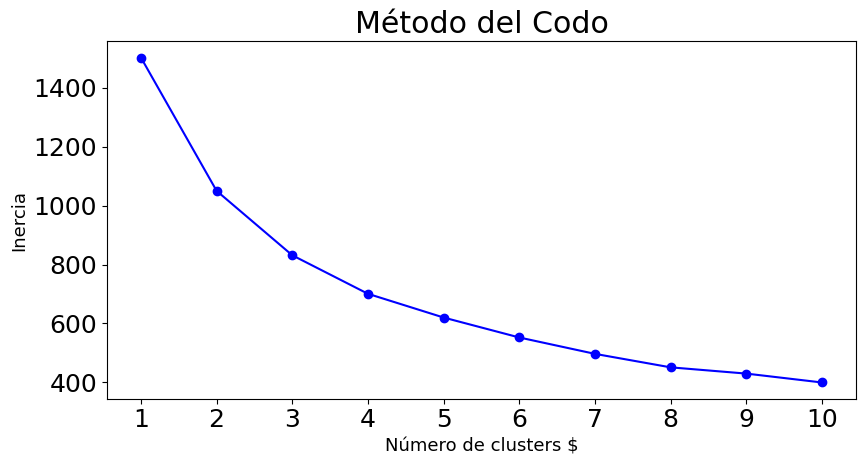

In [15]:
# Usamos los datos estandarizados de países del punto 1
# Método del codo: inercia para k = 1..10
inercias = []
k_range  = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(paises_std)
    inercias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inercias, "bo-")
plt.xlabel("Número de clusters $", fontsize=13)
plt.ylabel("Inercia", fontsize=13)
plt.title("Método del Codo")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

## 2.3 Método de la Silueta

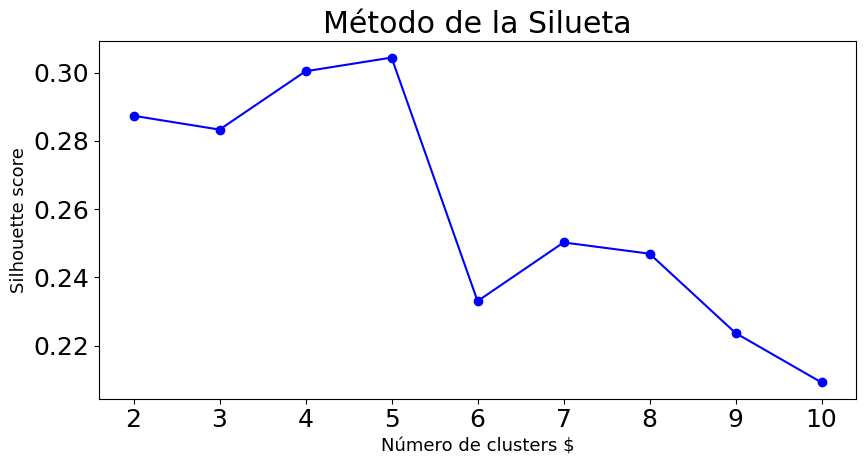

In [16]:
# Silhouette score para k = 2..10
silhouette_scores = []
k_range2 = range(2, 11)

for k in k_range2:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(paises_std)
    silhouette_scores.append(silhouette_score(paises_std, km.labels_))

plt.figure(figsize=(9, 5))
plt.plot(list(k_range2), silhouette_scores, "bo-")
plt.xlabel("Número de clusters $", fontsize=13)
plt.ylabel("Silhouette score", fontsize=13)
plt.title("Método de la Silueta")
plt.xticks(list(k_range2))
plt.tight_layout()
plt.show()

## 2.4 Ajuste del modelo final

In [18]:
# Seleccionar k óptimo según el codo y silueta (ajustar según resultados)
k_optimo = 3

kmeans_final = KMeans(n_clusters=k_optimo, random_state=0, n_init=10)
kmeans_final.fit(paises_std)

print("Inercia:", kmeans_final.inertia_)
print("Centroides:", kmeans_final.cluster_centers_)

Inercia: 831.424435208687
Centroides: [[-0.40645337 -0.03165259 -0.2244709   0.02416161 -0.25177041 -0.01716742
   0.25473362 -0.42434279 -0.35448141]
 [ 1.36021776 -0.43753313 -0.15598401 -0.18920377 -0.68689408  0.40211078
  -1.28217981  1.36494385 -0.60424243]
 [-0.82744866  0.64507985  0.72741122  0.19063895  1.48424268 -0.48492064
   1.07957853 -0.79187687  1.61599536]]


In [19]:
# Agregar etiquetas al dataframe de países
paises_cluster = paises_num.copy()
paises_cluster["cluster"] = kmeans_final.labels_
paises_cluster["Pais"]    = nombres_paises.values
paises_cluster.head(10)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster,Pais
0,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,1,Afghanistan
1,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,0,Albania
2,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,0,Algeria
3,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,1,Angola
4,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,0,Antigua and Barbuda
5,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300,0,Argentina
6,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220,0,Armenia
7,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,2,Australia
8,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,2,Austria
9,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840,0,Azerbaijan


In [20]:
# Estadísticas por cluster
paises_cluster.groupby("cluster").mean(numeric_only=True).round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44


## 2.5 Visualización de clusters sobre las componentes PCA

In [21]:
proyecciones["cluster"] = kmeans_final.labels_.astype(str)

fig = px.scatter(proyecciones,
                 x="PC1", y="PC2",
                 color="cluster",
                 text="Pais",
                 title=f"K-means (k={k_optimo}) sobre componentes PCA")
fig.update_traces(textposition="top center")
fig.show()

## 2.6 Conclusiones K-means

> *Escriba sus conclusiones: qué número de k eligió y por qué, cómo se caracterizan los clusters encontrados, qué países quedan agrupados juntos y qué significado tiene eso económica/socialmente.*

# <FONT COLOR="Purple"> 3. Métodos de Ensamble </FONT>

## 3.1 Librerías

In [22]:
# Instalar xgboost si no está disponible
# !pip install xgboost -q

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder
from sklearn.ensemble         import RandomForestRegressor
from xgboost                  import XGBRegressor
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## 3.2 Cargar y explorar los datos

In [23]:
ventas = pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_ventas.csv")
ventas.head(10)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
5,10.81,124,113,13,501,72,Bad,78,16,No,Yes
6,6.63,115,105,0,45,108,Medium,71,15,Yes,No
7,11.85,136,81,15,425,120,Good,67,10,Yes,Yes
8,6.54,132,110,0,108,124,Medium,76,10,No,No
9,4.69,132,113,0,131,124,Medium,76,17,No,Yes


In [24]:
# Información general
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


In [25]:
# Estadísticas descriptivas
ventas.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


In [26]:
# Verificar valores faltantes
ventas.isna().sum()

,0
Sales,0
CompPrice,0
Income,0
Advertising,0
Population,0
Price,0
ShelveLoc,0
Age,0
Education,0
Urban,0


In [27]:
# Distribución de la variable objetivo
import plotly.express as px
fig = px.histogram(ventas, x="Sales", nbins=30, title="Distribución de Ventas")
fig.show()

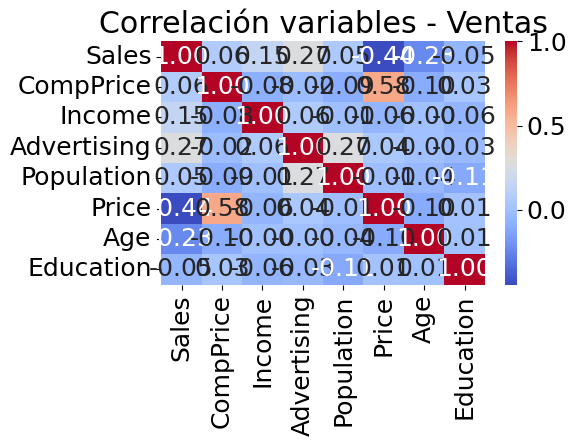

In [28]:
# Correlación variables numéricas
corr_v = ventas.select_dtypes(include="number").corr()
sns.heatmap(corr_v, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación variables - Ventas")
plt.tight_layout()
plt.show()

## 3.3 Preprocesamiento

In [29]:
# Codificar variables categóricas con LabelEncoder
ventas_enc = ventas.copy()
le = LabelEncoder()

for col in ventas_enc.select_dtypes(include="object").columns:
    ventas_enc[col] = le.fit_transform(ventas_enc[col])

ventas_enc.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,0,42,17,1,1
1,11.22,111,48,16,260,83,1,65,10,1,1
2,10.06,113,35,10,269,80,2,59,12,1,1
3,7.40,117,100,4,466,97,2,55,14,1,1
4,4.15,141,64,3,340,128,0,38,13,1,0


In [30]:
# Separar predictoras y variable objetivo
X = ventas_enc.drop("Sales", axis=1)
y = ventas_enc["Sales"]

# Conjunto de entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     random_state=0,
                                                     test_size=0.3)
print("Entrenamiento:", X_train.shape, "  Prueba:", X_test.shape)

Entrenamiento: (280, 10)   Prueba: (120, 10)


## 3.4 Random Forest

In [31]:
modelo_rf = RandomForestRegressor(n_estimators=300,
                                  max_depth=None,
                                  min_samples_split=2,
                                  min_samples_leaf=1,
                                  max_features="sqrt",
                                  bootstrap=True,
                                  random_state=123)
modelo_rf.fit(X_train, y_train)

RandomForestRegressor(max_features='sqrt', n_estimators=300, random_state=123)

In [32]:
# Métricas Random Forest
y_pred_rf = modelo_rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"RMSE : {rmse_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")

=== Random Forest ===
RMSE : 1.6283
MAE  : 1.3105
R²   : 0.6056


## 3.5 XGBoost

In [33]:
modelo_xgb = XGBRegressor(n_estimators=400,
                         learning_rate=0.05,
                         max_depth=4,
                         subsample=0.9,
                         colsample_bytree=0.9,
                         objective="reg:squarederror",
                         random_state=123)
modelo_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [34]:
# Métricas XGBoost
y_pred_xgb = modelo_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("=== XGBoost ===")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"MAE  : {mae_xgb:.4f}")
print(f"R²   : {r2_xgb:.4f}")

=== XGBoost ===
RMSE : 1.4263
MAE  : 1.1471
R²   : 0.6974


## 3.6 Comparación de modelos

       Modelo     RMSE     MAE       R2
Random Forest 1.628349 1.31050 0.605570
      XGBoost 1.426280 1.14711 0.697389


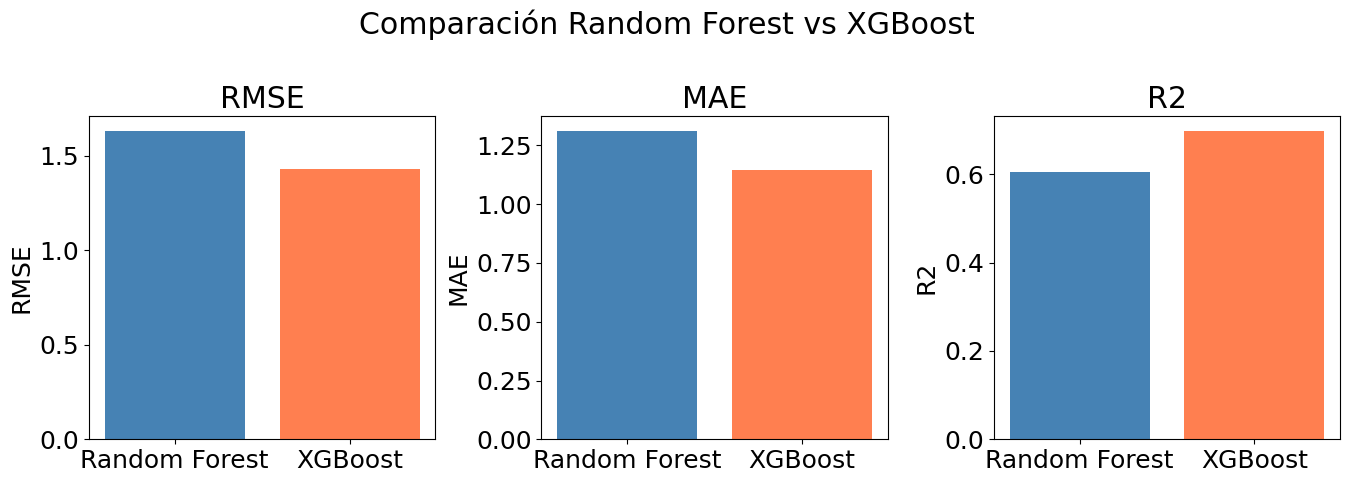

In [35]:
comparacion = pd.DataFrame({
    "Modelo": ["Random Forest", "XGBoost"],
    "RMSE"  : [rmse_rf, rmse_xgb],
    "MAE"   : [mae_rf,  mae_xgb],
    "R2"    : [r2_rf,   r2_xgb]
})
print(comparacion.to_string(index=False))

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    ax.bar(comparacion["Modelo"], comparacion[metric], color=["steelblue", "coral"])
    ax.set_title(metric)
    ax.set_ylabel(metric)
plt.suptitle("Comparación Random Forest vs XGBoost")
plt.tight_layout()
plt.show()

## 3.7 Variables más influyentes

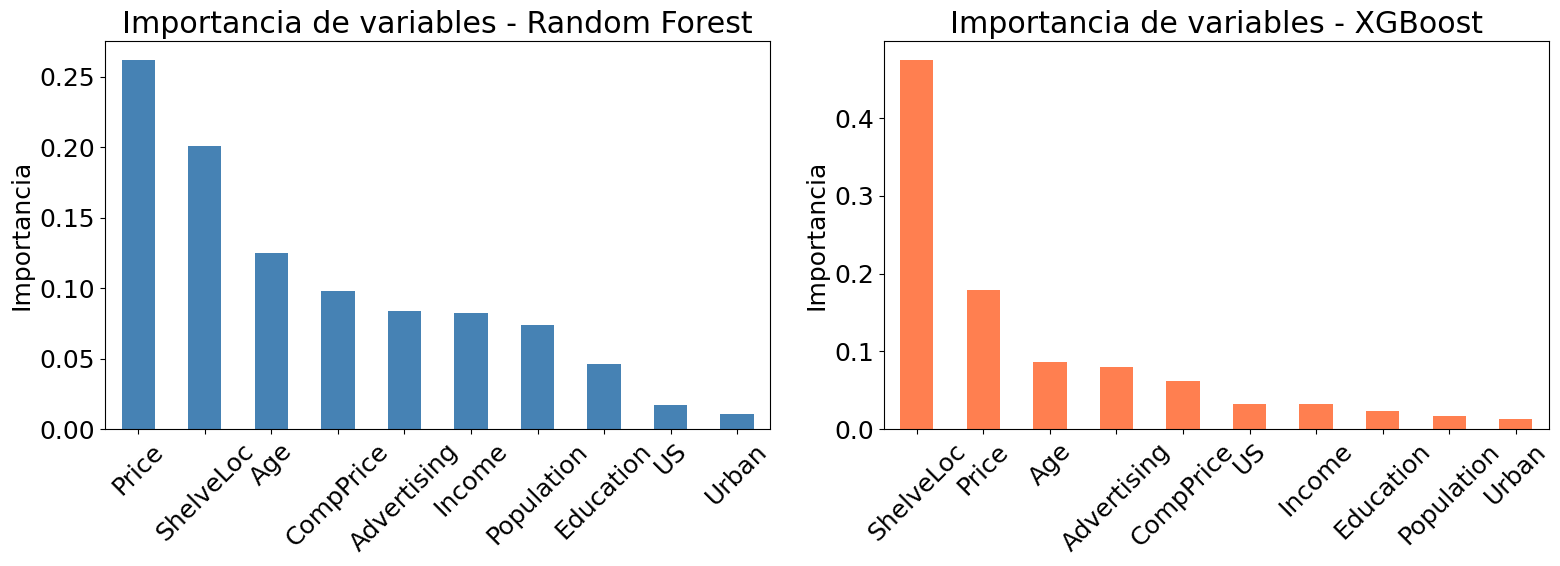

In [36]:
# Importancia de variables - Random Forest
importancia_rf = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

importancia_rf.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Importancia de variables - Random Forest")
axes[0].set_ylabel("Importancia")
axes[0].tick_params(axis="x", rotation=45)

# Importancia de variables - XGBoost
importancia_xgb = pd.Series(modelo_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
importancia_xgb.plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Importancia de variables - XGBoost")
axes[1].set_ylabel("Importancia")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 3.8 Predicciones

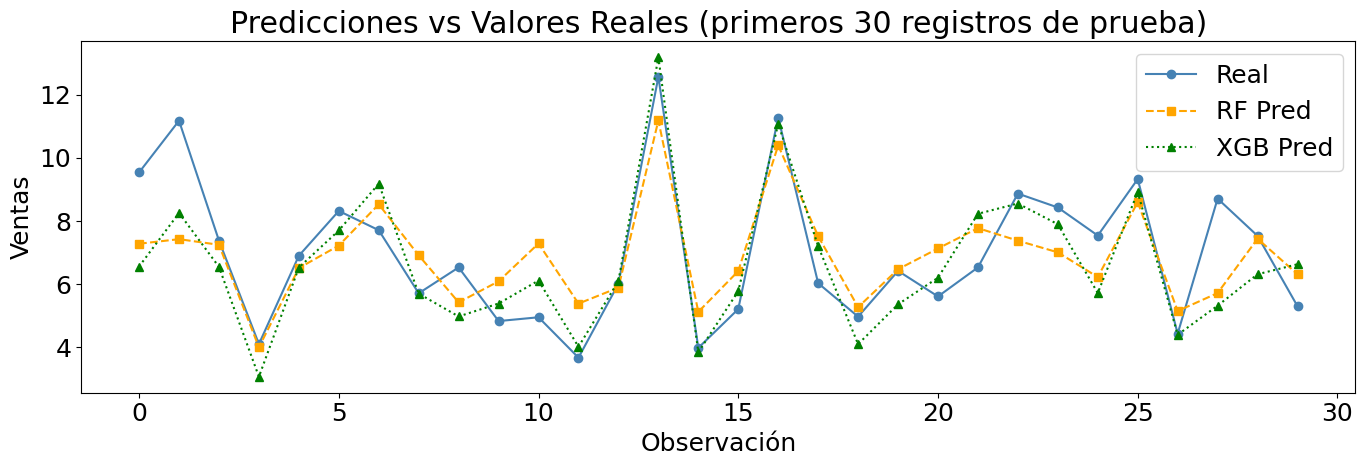

In [37]:
# Comparar predicciones vs valores reales (primeros 30 del test)
n_show = 30
indices = range(n_show)

plt.figure(figsize=(14, 5))
plt.plot(indices, y_test.values[:n_show], "o-", label="Real",       color="steelblue")
plt.plot(indices, y_pred_rf[:n_show],      "s--",label="RF Pred",    color="orange")
plt.plot(indices, y_pred_xgb[:n_show],     "^:", label="XGB Pred",   color="green")
plt.xlabel("Observación")
plt.ylabel("Ventas")
plt.title("Predicciones vs Valores Reales (primeros 30 registros de prueba)")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
# Ejemplo de nuevas predicciones
# [CompPrice, Income, Advertising, Population, Price, ShelveLoc, Age, Education, Urban, US]
nuevos = pd.DataFrame({
    "CompPrice"  : [120, 145],
    "Income"     : [60,  90],
    "Advertising": [5,   15],
    "Population" : [300, 500],
    "Price"      : [110, 130],
    "ShelveLoc"  : [1,   2],    # 0=Bad, 1=Good, 2=Medium (según LabelEncoder)
    "Age"        : [45,  35],
    "Education"  : [14,  16],
    "Urban"      : [1,   1],    # 1=Yes
    "US"         : [1,   0]     # 1=Yes
})

pred_rf_new  = modelo_rf.predict(nuevos)
pred_xgb_new = modelo_xgb.predict(nuevos)

print("Predicciones para nuevos datos:")
for i in range(len(nuevos)):
    print(f"  Caso {i+1} -> RF: {pred_rf_new[i]:.2f}  |  XGBoost: {pred_xgb_new[i]:.2f}")

Predicciones para nuevos datos:
  Caso 1 -> RF: 9.12  |  XGBoost: 8.47
  Caso 2 -> RF: 8.73  |  XGBoost: 9.48


## 3.9 Conclusiones Métodos de Ensamble

> *Escriba sus conclusiones: cuál modelo tuvo mejor desempeño y por qué, qué variables son las más influyentes en la predicción de ventas, qué implicaciones tiene esto para la empresa.*